<img src="https://datascientest.fr/train/assets/logo_datascientest.png" style="height:150px">

<hr style="border-width:2px;border-color:#75DFC1">
<h1><center>Masterclass — Model Interpretability</center></h1>
<hr style="border-width:2px;border-color:#75DFC1">

## 🎯 What you will be able to do by the end of this notebook

1. **Explain** why interpretability matters in real ML projects — not just for performance, but for trust, fairness, and regulation
2. **Use traditional techniques** (feature importance, coefficients, PCA) and articulate their limitations
3. **Apply SHAP** to tree-based models to get both global and local explanations
4. **Read and interpret** SHAP summary plots, dependence plots, and force plots confidently
5. **Extend SHAP** to multiclass text classification
6. **Run an independent challenge** — apply everything to a new dataset on your own

---

## 🧭 How to use this notebook

- **Run one block, then pause**: after each plot, try to answer the prompt *before* reading the explanation
- **Keep two lenses in mind**: *performance* (is the model good?) and *responsibility* (is the reasoning acceptable?)
- **Treat human-related features carefully**: variables such as age, gender, or marital status describe patterns in data — they never define the worth or ability of a person
- **Use the visuals actively**: this notebook is designed to be read with the charts, not just around them

---

## 🗺️ Roadmap

| Part | Question we'll answer | Data | Main visual |
|------|------------------------|------|-------------|
| **Part 1** | How far can classic interpretability take us? | Census (tabular) | Tree, coefficients, PCA, SHAP |
| **Part 2** | Does the same logic work on text and multiclass problems? | Emotions (text) | Multiclass force plots |
| **Part 3** | Can you run the full workflow alone? | Your choice | Your own SHAP analysis |

---

## 🐺 Why does interpretability matter? A concrete example

Imagine a team builds a wolf vs. dog image classifier. It reaches **98% accuracy** on the test set. Impressive — ship it?

Not so fast.

<center><img src="https://datascientest.fr/train/assets/chien-loup.jpg" style="height:260px"></center>

Using an interpretation method, the team discovers the model is **not looking at the animals at all** — it's classifying based on background pixels. Wolves appear in snowy forests; dogs appear indoors. The model learned the background, not the animal.

<center><img src="https://datascientest.fr/train/assets/chien-loup-2.jpg" style="height:260px"></center>

**High accuracy ≠ correct reasoning.** Without interpretability, this bug stays hidden until the model fails in production.

---

## 🏦 The real-world stakes

Consider a bank that uses an ML model to support loan eligibility decisions. The model is accurate — but when a customer is rejected, the loan officer **cannot explain why**. In France and the EU, the GDPR's "right to explanation" has made explainability a practical and legal concern. A Data Scientist's job is not only to train a good model, but also to make its reasoning understandable to the people affected by it.

This is the core challenge we'll address throughout this notebook.

---

## 📐 Two key dimensions of interpretability

**Scope** — *What level does the explanation target?*
- **Global**: How does the model behave overall? Which features matter most across all predictions?
- **Local**: Why did the model make *this specific prediction* for *this specific person*?

**Method type** — *When is the explanation generated?*
- **Intrinsic**: Built into the model itself (e.g. decision trees, linear regression coefficients)
- **Post hoc**: Applied after training to explain a black-box model (e.g. SHAP, LIME)

In this notebook, we'll move from intrinsic methods (simple models you can inspect directly) to post hoc methods (powerful models explained after training).

---

Let's start. We'll predict whether an individual earns more or less than $50K/year using census data — a dataset with human-readable features that makes interpretability intuitive.

* (a) Import the necessary packages.



In [ ]:
# ── Data manipulation ──────────────────────────────────────────────────────────
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ── Preprocessing & model selection ───────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ── Models ─────────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import xgboost as xgb  # gradient boosting — our "black box" model to explain

# ── Interpretability ───────────────────────────────────────────────────────────
import shap             # SHapley Additive exPlanations — the main tool in this notebook

from IPython.display import display
pd.set_option('display.max_columns', None)
%matplotlib inline

---

## 📊 Part 1 — Binary Classification on Tabular Data (Census)

### Part 1a — Data Preparation & Baseline Models

**Dataset**: US Census data — predict whether an individual earns more or less than $50K/year.

**Features**: age, education level, marital status, occupation, gender, capital gain/loss, hours worked per week, native country.

**Why this dataset?** Features are intuitive and human-readable — perfect for learning interpretability. When SHAP tells us "marital status matters", we can reason about whether that makes sense.

**What to watch for in this part:**
- how preprocessing changes raw data into model-ready inputs
- how model performance changes when we move from simple to complex models
- how explanation quality changes depending on the model family

* (b) Load `census_data_v1.csv` into a DataFrame.



In [ ]:
# Insert your code here

In [2]:
df = pd.read_csv('census_data_v1.csv')

* (c) Let's take a quick look at the dataset, as well as the distribution of the target variable.

In [ ]:
# Insert your code here

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              45222 non-null  int64 
 1   workclass        45222 non-null  object
 2   educational-num  45222 non-null  int64 
 3   marital-status   45222 non-null  object
 4   occupation       45222 non-null  object
 5   gender           45222 non-null  object
 6   capital-gain     45222 non-null  int64 
 7   capital-loss     45222 non-null  int64 
 8   hours-per-week   45222 non-null  int64 
 9   native-country   45222 non-null  object
 10  income           45222 non-null  object
dtypes: int64(5), object(6)
memory usage: 3.8+ MB


None

,age,workclass,educational-num,marital-status,occupation,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,7,Never-married,Machine-op-inspct,Male,0,0,40,Canada&USA,<=50K
1,38,Private,9,Married,Farming-fishing,Male,0,0,50,Canada&USA,<=50K
2,28,Local-gov,12,Married,Protective-serv,Male,0,0,40,Canada&USA,>50K
3,44,Private,10,Married,Machine-op-inspct,Male,7688,0,40,Canada&USA,>50K
4,34,Private,6,Never-married,Other-service,Male,0,0,30,Canada&USA,<=50K


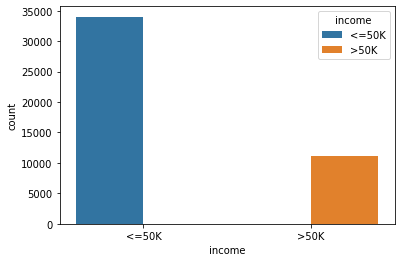

In [3]:
# Display dataset information
display(df.info())

# Display the first 5 rows of the dataset
display(df.head())

# Display the distribution of the target variable
sns.countplot(x="income", data=df, hue="income");

* (d) Check for missing values in the dataset. Then, separate the explanatory variables (features) from the target variable `income`.

In [ ]:
# Insert your code here

In [4]:
# Splitting the data into explanatory variables and target variable
print(df.isna().sum())
X = df.drop(columns='income')
# or X = df.drop('income', axis=1)
y = df['income']

age                0
workclass          0
educational-num    0
marital-status     0
occupation         0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64


* (e) Split the data into a training set and a test set.

In [ ]:
# Insert your code here

In [ ]:
X = df.drop(columns='income')
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train / 20% test — standard split for this dataset size
    stratify=y,          # stratify: keeps the same class ratio in train and test (important for imbalanced targets)
    random_state=333     # fixed seed for reproducibility — change this number to check robustness
)

print(f'Training set:  {X_train.shape[0]:,} rows × {X_train.shape[1]} columns')
print(f'Test set:      {X_test.shape[0]:,} rows  × {X_test.shape[1]} columns')

> 🔁 **Transition**: before any model can learn from this dataset, categories such as occupation or marital status must be turned into numbers. We'll use `OneHotEncoder` for that, and we will also encode the target labels so the classifiers can optimize properly.

* (f) Encode the categorical variables in `X_train` and `X_test` using the `OneHotEncoder` transformer. Also, encode the target variable `y` by replacing the strings with numerical values 0 and 1.



In [ ]:
# Insert your code here

In [ ]:
# ── Step 1: identify which columns are categorical vs numerical ────────────────
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols   = X_train.select_dtypes(exclude=['object']).columns.tolist()

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical columns  ({len(numerical_cols)}): {numerical_cols}")

# ── Step 2: one-hot encode categorical columns ─────────────────────────────────
# sparse=False: return a dense array (required for pandas concat below)
# handle_unknown='ignore': if test set has a category not seen in train, just put zeros
ohe = OneHotEncoder(sparse=False, handle_unknown='ignore')

X_train_cat_encoded = ohe.fit_transform(X_train[categorical_cols])  # fit on train
X_test_cat_encoded  = ohe.transform(X_test[categorical_cols])        # transform test only

# ── Step 3: recover column names after encoding ────────────────────────────────
encoded_cat_columns = ohe.get_feature_names_out(categorical_cols)
# e.g. "workclass" becomes "workclass_Private", "workclass_Self-emp", etc.

# ── Step 4: rebuild DataFrames with proper column names ───────────────────────
X_train_cat_df = pd.DataFrame(X_train_cat_encoded, columns=encoded_cat_columns, index=X_train.index)
X_test_cat_df  = pd.DataFrame(X_test_cat_encoded,  columns=encoded_cat_columns, index=X_test.index)

# ── Step 5: concatenate numerical + encoded categorical ────────────────────────
# reset_index() is needed because train/test split reorders indices
X_train_final = pd.concat([X_train[numerical_cols].reset_index(drop=True), X_train_cat_df.reset_index(drop=True)], axis=1)
X_test_final  = pd.concat([X_test[numerical_cols].reset_index(drop=True),  X_test_cat_df.reset_index(drop=True)],  axis=1)

# ── Step 6: encode target variable (string → 0/1) ─────────────────────────────
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)   # "<=50K" → 0, ">50K" → 1
y_test_encoded  = label_encoder.transform(y_test)

print(f'\nX_train_final: {X_train_final.shape[0]:,} rows × {X_train_final.shape[1]} columns')
print(f'X_test_final:  {X_test_final.shape[0]:,} rows × {X_test_final.shape[1]} columns')
print(f'Classes: {label_encoder.classes_}  →  encoded as {[0, 1]}')

### Training baseline models

We'll train two intentionally simple models:
- **Decision Tree** (`max_depth=3`): interpretable by design, but limited in what it can capture
- **Logistic Regression**: interpretable through coefficients, but assumes mostly linear relationships

These models are not here to "win" on performance. They are our **reference points**: if a more powerful model performs better later, we want to understand what interpretability we lose — and how SHAP helps us recover it.

* (g) Train a decision tree classifier.
* (h) Evaluate it using cross-validation (F1 + accuracy).



In [ ]:
# Insert your code here

In [ ]:
# max_depth=3: we intentionally keep the tree shallow.
# A deeper tree would be more accurate but harder to visualize and interpret —
# which defeats the purpose of using a decision tree for interpretability.
# Try changing this to 5 or 10 to see how the tree becomes unreadable.
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_train_final, y_train_encoded)

print("Validation Mean F1 Score: ", cross_val_score(
    tree_clf, X_train_final, y_train_encoded, cv=5, scoring='f1_macro').mean().round(3))

print("Validation Mean Accuracy: ", cross_val_score(
    tree_clf, X_train_final, y_train_encoded, cv=5, scoring='accuracy').mean().round(3))

* (i) Let's display the classification report for more details.

In [ ]:
# Insert your code here

In [8]:
y_pred = tree_clf.predict(X_test_final)
print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.95      0.90      6803
           1       0.75      0.50      0.60      2242

    accuracy                           0.84      9045
   macro avg       0.80      0.72      0.75      9045
weighted avg       0.83      0.84      0.82      9045



* (l) Let's scale the variables of our model before training our logistic regression.

In [ ]:
# Insert your code here

In [ ]:
# Logistic regression requires feature scaling — coefficients are only comparable
# when all features are on the same scale (StandardScaler → mean=0, std=1).
# We use a Pipeline to ensure the scaler is fit on training data only (no leakage).
scaler = StandardScaler()
lr = LogisticRegression(
    solver='liblinear',  # efficient for smaller datasets; supports L1 & L2 regularization
    max_iter=1000        # increase iterations to ensure convergence
)

pipeline = Pipeline(steps=[
    ('normalization', scaler),
    ('logistic_regression', lr)
])

pipeline.fit(X_train_final, y_train_encoded)

print("Validation Mean F1 Score: ", round(cross_val_score(
    pipeline, X_train_final, y_train_encoded, cv=5, scoring='f1_macro').mean(), 3))
print("Validation Mean Accuracy: ", round(cross_val_score(
    pipeline, X_train_final, y_train_encoded, cv=5, scoring='accuracy').mean(), 3))

* (m) We train the logistic regression model and display the classification report.

In [ ]:
# Insert your code here

In [10]:
y_pred = pipeline.predict(X_test_final)
print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90      6803
           1       0.74      0.59      0.66      2242

    accuracy                           0.85      9045
   macro avg       0.80      0.76      0.78      9045
weighted avg       0.84      0.85      0.84      9045



---

## 🌳 Part 1b — Traditional Interpretability Techniques (and Their Limits)

Before SHAP, practitioners used simpler methods to understand models. We'll explore three of them — then show why they're not enough.

| Technique | Type | Works on | Limitation |
|-----------|------|----------|------------|
| Decision tree visualization | Intrinsic | Trees only | Only shallow trees are readable |
| Feature importance | Intrinsic | Trees, forests | Unstable; tied to tree structure |
| Regression coefficients | Intrinsic | Linear models only | Assumes linearity; no interactions |
| PCA biplot | Global, post hoc | Any model | Projection — loses information |

> 🎯 **Goal of this section**: Understand *why* these traditional methods are insufficient for complex models — motivating the need for SHAP.

---

> It is possible to display a tree representing a model's decisions using the `plot_tree` function.

* (a) Display the decision tree.

### 📖 Before you run this: how to read a decision tree

A decision tree is a series of **yes/no questions** that leads to a prediction. Here's what to look for when the plot appears:

```
                    [ROOT NODE]
                   some_feature ≤ X
                  /               \
              True                False
          [left child]        [right child]
          ...                 ...
            |                   |
          [LEAF]              [LEAF]
         class: A            class: B
```

**Inside each box:**
| Field | Meaning |
|-------|---------|
| `feature ≤ value` | The split rule (go left if True, right if False) |
| `gini` | Impurity: 0 = perfectly pure (all one class), 0.5 = maximally mixed |
| `samples` | How many training examples reached this node |
| `value: [n_0, n_1]` | Count of class 0 and class 1 at this node |
| `class` | Majority class → the prediction here |

**Reading a path:**  
Start at the top. At each node, ask the question. Follow left if True, right if False. When you reach a leaf (no children), that's the prediction.

> 💡 **What to notice:** Which feature appears at the root (the very first split)? That's the single most powerful separator in the dataset.

In [ ]:
# Insert your code here

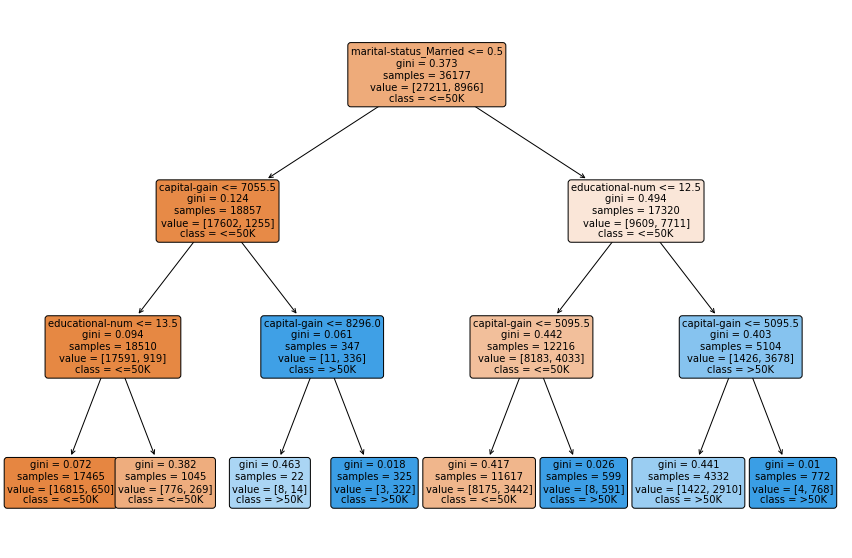

In [11]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))
plot_tree(tree_clf, 
          feature_names=list(X_train_final.columns), 
          class_names=label_encoder.classes_, 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.show()

### ✅ Reading the tree: key observations

Now that you've seen the tree, apply what you read above:

1. **Root split**: What is the first question? Which feature splits the data most cleanly?
2. **Dominant class per leaf**: Are the leaves pure (low gini) or mixed?
3. **Feature coverage**: With `max_depth=3`, only 3 features are used. What are they? Does this match your intuition about income prediction?

> 💬 **Discussion**: Notice how only `marital-status_Married`, `capital-gain`, and `educational-num` appear. This is both a strength (interpretable!) and a weakness (it ignores all other features). This is why shallow trees have limited performance — and why we'll need more powerful models later.

> ⚠️ **Limitation of decision tree feature importance**: The importance scores are tied to this specific tree structure. Tiny changes in training data can completely change which features are selected (trees are unstable). This is not a reliable measure of "true" feature importance.

> We can read this tree from top to bottom because it is deliberately shallow. That gives us something rare in machine learning: a model we can inspect almost line by line.
>
> **What this tree gives us**
> - a **global view** of the main decision rules
> - a **local view** of one person's path through the tree
>
> **What this tree does *not* give us**
> - rich interactions between many variables
> - strong predictive performance
> - a method that transfers to non-tree models
>
> Feature importance is the natural next step: instead of reading one branch at a time, we ask which variables contributed the most to the whole tree.

* (b) Let's display the top 3 most important variables for the `tree_clf` model.



In [ ]:
# Insert your code here

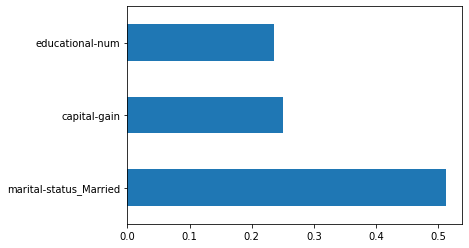

In [12]:
feat_importances = pd.Series(
    tree_clf.feature_importances_, X_train_final.columns)
feat_importances.nlargest(3).plot(kind='barh');

> ⚠️ **Interpret carefully**: in a single decision tree, feature importance is tightly tied to the exact tree structure. A small change in the training data can produce a different tree — and a different ranking.
>
> That makes tree-based importance useful for intuition, but weak as a stable explanation.
>
> 🔁 **Next transition**: to get another interpretable point of view, let's switch to a linear model and inspect its coefficients.

* (c) To gain more interpretability in regression models, the best approach is to display the coefficients associated with each explanatory variable.



In [ ]:
# Insert your code here

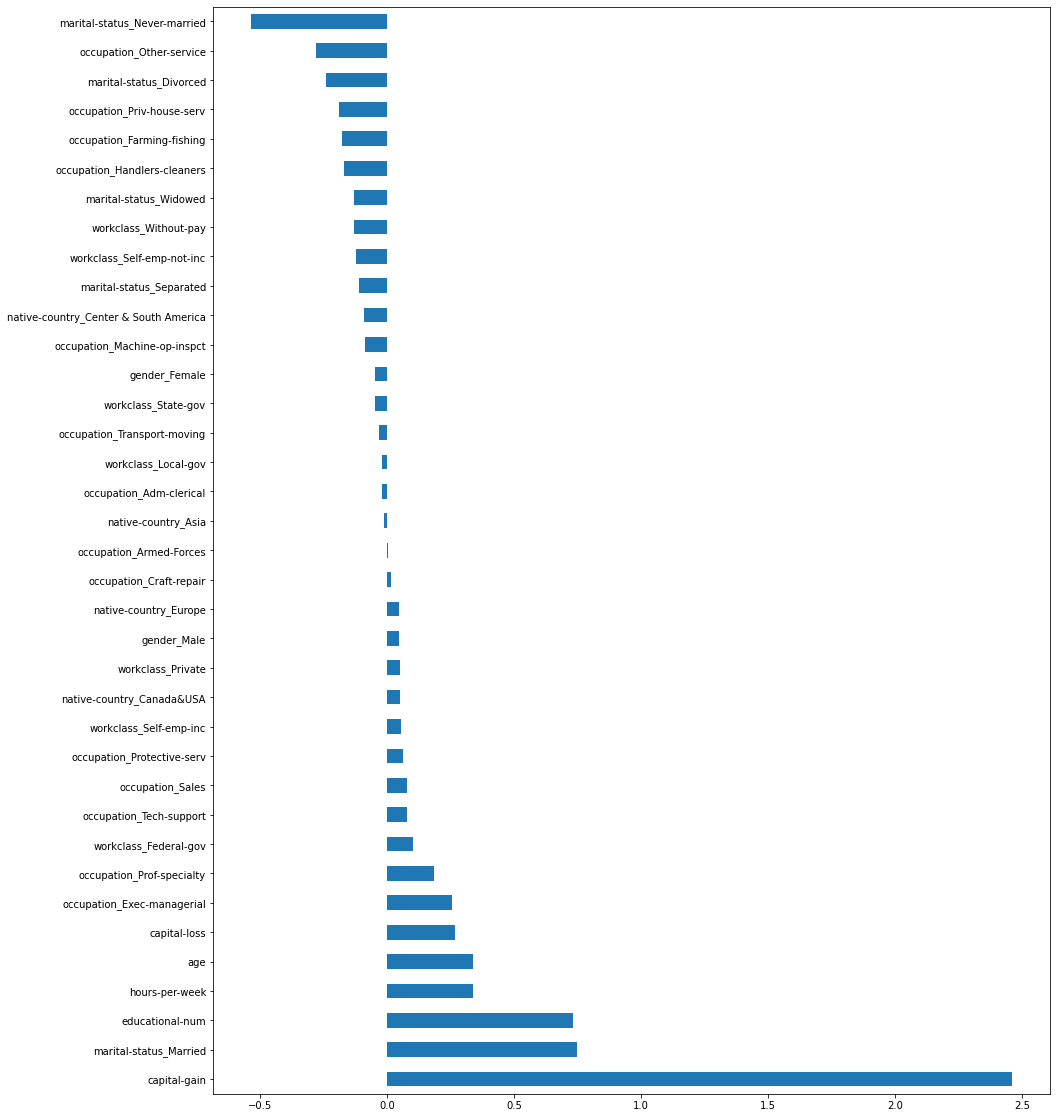

In [13]:
pd.Series(pipeline.get_params()["logistic_regression"].coef_[0], X_train_final.columns).sort_values(ascending=False).plot(kind='barh', figsize=(15,20));

> Logistic regression coefficients tell us the **direction** of association learned by the model: positive coefficients push the prediction toward `>50K`, and negative coefficients push it toward `≤50K`.
>
> But coefficients are not self-explanatory. To read them well, keep four cautions in mind:
> - **scale matters**: coefficients are only comparable after proper scaling
> - **correlation matters**: two related variables can split or hide each other's effect
> - **correlation is not causation**: the model learns patterns, not reasons
> - **sensitive features require care**: if gender or marital status appear important, that is a signal to audit the model — not to essentialize people
>
> Another way to obtain a more visual global view is to project the data and the learned structure into two dimensions with PCA.

* (d) Let's try to analyze the results of our logistic regression model.



### 📖 Before you run this: how to read a PCA biplot

A PCA biplot overlays **two things** on the same 2D chart:
- **Points** (one per person) projected onto the first two principal components
- **Arrows** (one per feature) showing the direction and strength of each feature

```
          PC2 ▲
              │    ● ● ○ ○ ○
   ↑ arrow   │  ● ● ○ ○ ○
   for feat  │● ●● ○ ○ ○
    A        │  ● ○ ○ ○ ○
             └──────────────► PC1
                  → arrow for feature B
```

**Reading rules:**
| Element | What it tells you |
|---------|-------------------|
| **Point color** | Predicted income class (0 = ≤50K, 1 = >50K) |
| **Arrow direction** | Where that feature is *high* — points projected in that direction tend to have high values for it |
| **Arrow length** | How much that feature contributes to the PC1/PC2 axes (longer = more influential in this projection) |
| **Arrow into orange zone** | High values of this feature tend to be associated with the >50K class |
| **Arrow into blue zone** | High values tend to associate with ≤50K |

> 💡 **What to notice:** Do the arrows for `marital-status_Married` and `capital-gain` point into the same region as the orange (>50K) cluster? If yes, it confirms what the tree already showed us.

In [ ]:
# Insert your code here

(-0.8, 0.8)

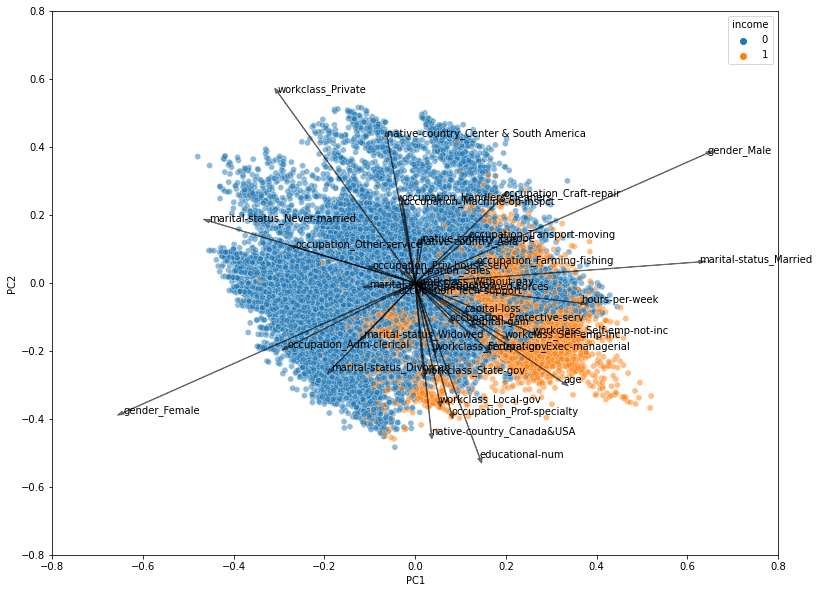

In [15]:
from sklearn.decomposition import PCA

n = X_train_final.shape[1]

pca = PCA(n_components=2)

scaler = StandardScaler()

pipeline_pca = Pipeline(steps = [('normalization', scaler),
                                 ('pca', pca)])

X_new = pipeline_pca.fit_transform(X_train_final)

coeff = pca.components_.transpose()

xs = X_new[:, 0]
ys = X_new[:, 1]
scalex = 1.0/(xs.max() - xs.min())
scaley = 1.0/(ys.max() - ys.min())


principalDf = pd.DataFrame({'PC1': xs*scalex, 'PC2': ys * scaley})

y_train_pred = pipeline.predict(X_train_final)
finalDF = pd.concat([principalDf, pd.Series(
    y_train_pred, name='income')], axis=1)


plt.figure(figsize=(13, 10))

sns.scatterplot(x='PC1', y='PC2', hue='income', data=finalDF, alpha=0.5)

for i in range(n):
    plt.arrow(0, 0, coeff[i, 0]*1.5, coeff[i, 1]*1.5,
              color='k', alpha=0.5, head_width=0.01, )
    plt.text(coeff[i, 0]*1.5, coeff[i, 1] * 1.5, X_train_final.columns[i], color='k')

plt.xlim(-0.8, 0.8)
plt.ylim(-0.8, 0.8)

### ✅ Reading the PCA biplot: key observations

Apply the rules from above:

1. **Cluster separation**: Are the orange (>50K) and blue (≤50K) points visibly separated? In which direction?
2. **Arrow alignment**: Do `marital-status_Married`, `capital-gain`, and `educational-num` point toward the orange cluster?
3. **Gender arrow**: Where does `gender_Female` point? What does this suggest about the model's learned associations?

> 💬 **Discussion**: If the model has learned that being female correlates with lower income, that's a **fairness concern** — the model may be encoding historical societal bias, not a causal relationship. This is exactly why interpretability tools exist: to surface these patterns before the model makes real decisions.

> ⚠️ **Limitation of PCA for interpretability**: PCA is useful for exploring global structure, but it's a projection — it loses information. Two features can look uncorrelated in 2D but have real interactions in higher dimensions. It's an exploratory tool, not a conclusive one.

## ⚡ From Interpretable Models to Black Boxes — The Performance/Interpretability Gap

So far we've used two interpretable models:
- **Decision tree** (max_depth=3): Easy to visualize, but low performance (F1 ≈ 0.75). It misses complex patterns.
- **Logistic regression**: Slightly better (F1 ≈ 0.78), coefficients are readable — but assumes linear relationships between features and outcome.

| Model | F1 score | Interpretable? |
|-------|----------|----------------|
| Decision tree (depth 3) | ~0.75 | ✅ Fully (by design) |
| Logistic regression | ~0.78 | ✅ Coefficients readable |
| XGBoost (next) | ~0.81 | ❌ Black box |

**Why move to XGBoost?**  
XGBoost is a gradient boosting algorithm — it builds hundreds of decision trees sequentially, each correcting the errors of the previous one. This gives it much better accuracy, but at the cost of interpretability: there is no single tree to look at, no single coefficient to read. The model's reasoning is spread across 100+ trees.

This is the classic **performance vs. interpretability tradeoff**.

> 💡 **The key question we'll answer with SHAP**: Can we get the performance of XGBoost *and* the interpretability of a decision tree? The answer is yes — by applying SHAP after training.

---

## 🔬 Part 1c — Model Interpretation with SHAP

**SHAP** (**SH**apley **A**dditive ex**P**lanations) is a post hoc interpretability method. It works on *any* model — after training — and answers: *"For this specific prediction, how much did each feature contribute?"*

The underlying math comes from **cooperative game theory** (Shapley values, 1953). Here's the intuition:

> Imagine features as players in a team game, where the "score" is the model's prediction. SHAP asks: *if we tried all possible subsets of players (features), how much does adding each player improve the team's score on average?* That average improvement is the Shapley value.

More concretely:
- The **expected value** is the model's average prediction across all training data (baseline)
- Each feature's **SHAP value** is its contribution above/below that baseline for a specific individual
- The sum of all SHAP values + expected value = the model's actual prediction for that individual

Let's see it in action.

* (a) Train the XGBoost model.

In [ ]:
# Insert your code here

In [ ]:
# XGBoost with default hyperparameters.
# Default settings: 100 trees (n_estimators), max_depth=6, learning_rate=0.3
# We're not tuning here — the goal is interpretability, not peak performance.
# For a production model, you'd run a grid search or use optuna/hyperopt.
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train_final, y_train_encoded)

> Let's make predictions with our `XGBoost` model and display the results.

* (b) Store the predicted labels from your model in a variable called `xgb_pred`, and the associated probabilities in a variable called `xgb_proba`. These probabilities will be useful in the next steps.

* (c) Display the classification report of your model.

In [ ]:
# Insert your code here

In [17]:
xgb_pred = model.predict(X_test_final)
xgb_proba = model.predict_proba(X_test_final)

print(classification_report(y_test_encoded, xgb_pred))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      6803
           1       0.77      0.66      0.71      2242

    accuracy                           0.87      9045
   macro avg       0.83      0.80      0.81      9045
weighted avg       0.86      0.87      0.86      9045



> The performance is already a little better than the shallow baselines, even without hyperparameter tuning. That is exactly why black-box models are tempting in practice.

### SHAP in one mental picture

Think of SHAP as a **prediction decomposition tool**:

```text
average prediction (baseline)
        +
feature 1 contribution
        +
feature 2 contribution
        +
...
        =
final prediction for one person
```

In other words:
- the **expected value** is the model's average prediction
- each **SHAP value** measures how one feature moved the prediction away from that baseline
- adding all SHAP values to the expected value gives back the final prediction

> 💡 **Why this is pedagogically powerful**: the same logic works for global plots, local plots, tabular data, and text. Only the *visualization* changes.

* (d) Let's analyze the predictions of our model with SHAP.



In [ ]:
# Insert your code here

In [ ]:
# TreeExplainer is the fastest SHAP explainer for tree-based models (XGBoost, LightGBM, Random Forest).
# It uses an exact algorithm — not approximations — which is why it's both fast and accurate.
#
# feature_perturbation="interventional": handles correlated features better than the default
#   "tree_path_dependent" — recommended when features may be correlated (as in tabular data).
#
# model_output="probability": SHAP values will be expressed as probability contributions
#   (easier to interpret than logits). Only available for binary classification.
#
# data=X_train_final: the reference dataset used to estimate the expected value (baseline).
#   Using the training set is standard practice.

explainer = shap.TreeExplainer(
    model,
    data=X_train_final,
    feature_perturbation="interventional",
    model_output="probability"
)

# Compute SHAP values for the entire test set.
# Result: a matrix of shape (n_test_samples, n_features).
# Each value tells us: "for this person, this feature shifted the predicted
# probability by +X or -X relative to the expected value."
shap_values = explainer.shap_values(X_test_final)
print(f"SHAP values shape: {shap_values.shape}  → ({X_test_final.shape[0]} test samples × {X_test_final.shape[1]} features)")

### From explainer output to readable data

The explainer returns a matrix of SHAP values:
- **rows** = people in the test set
- **columns** = features
- **cell `(i, j)`** = how much feature `j` changed the prediction for person `i`

A positive SHAP value pushes the prediction toward `>50K`; a negative value pushes it toward `≤50K`.

> 💡 **Reading tip**: at this stage, don't try to interpret every number. First, make sure you understand the *structure* of the output. The plots that follow will turn this matrix into something human-readable.

* (e) Let's display the Shapley values estimated by SHAP for each variable and each observation. To do this, let's create a `DataFrame` containing the Shapley values present in `shap_values`.



In [ ]:
# Insert your code here

In [19]:
print(shap_values.shape)
df_shap = pd.DataFrame(shap_values, columns = X_train_final.columns)
df_shap.head()

(9045, 37)


,age,educational-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,marital-status_Divorced,marital-status_Married,marital-status_Never-married,marital-status_Separated,marital-status_Widowed,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,gender_Female,gender_Male,native-country_Asia,native-country_Canada&USA,native-country_Center & South America,native-country_Europe
0,-0.028029,-0.003149,-0.055171,-0.009013,0.071180,-0.002283,0.003126,0.000199,-0.002432,0.009597,-0.000438,0.0,-0.000180,0.091597,0.008215,0.000129,-0.002100,0.001845,0.0,0.000232,-0.019645,0.004058,0.001145,-0.080224,0.004213,0.0,-0.006204,0.001551,-0.001711,-0.000456,0.003510,0.003722,0.0,0.000000,2.246197e-04,0.001133,-0.000992
1,-0.002746,-0.039084,0.507459,-0.004188,0.034350,-0.002725,0.003006,0.007627,-0.003329,-0.088799,0.004822,0.0,-0.000174,0.152930,0.017965,0.000353,-0.001185,0.002647,0.0,-0.021985,-0.003704,0.005360,0.001505,0.004049,0.014022,0.0,-0.010367,-0.000455,0.001905,-0.000868,0.002784,-0.005665,0.0,-0.000171,-3.002575e-04,0.001866,-0.000142
2,0.094461,-0.032690,-0.042360,-0.007120,0.083811,-0.002807,0.002801,-0.001964,-0.001706,0.011359,-0.001485,0.0,-0.000189,0.128572,0.011109,0.000179,-0.001108,0.003597,0.0,0.000410,-0.020830,0.005981,0.001025,-0.060387,0.006854,0.0,-0.006851,0.000992,-0.001322,-0.000453,0.001014,0.015854,0.0,0.000311,5.335928e-04,0.001602,-0.000978
3,-0.001950,0.006396,-0.054056,-0.004455,-0.012018,-0.001252,-0.001950,-0.007850,-0.000414,0.002267,0.002979,0.0,-0.001332,-0.108915,-0.016073,0.000051,-0.000241,0.002353,0.0,0.000683,-0.004858,0.003288,0.000348,0.002789,0.001450,0.0,-0.008658,-0.000555,-0.000589,0.000081,0.001381,-0.006022,0.0,-0.000021,-1.712042e-05,0.000279,-0.000676
4,0.055008,-0.018000,0.615592,-0.000164,0.055107,-0.000420,0.002446,0.010035,-0.000543,-0.014878,-0.001083,0.0,0.006147,-0.028290,0.015137,0.000493,-0.000255,-0.000876,0.0,0.001891,0.042465,0.001499,0.000186,0.002247,0.006086,0.0,-0.002088,-0.000790,-0.000557,-0.000465,0.001297,0.010208,0.0,0.000077,3.615605e-07,0.001142,-0.000021


### Understanding the SHAP output structure

The SHAP DataFrame you just created is the core output. Here's how to read it:

| Element | Shape | Meaning |
|---------|-------|---------|
| `shap_values` array | (9045, 37) | One SHAP value per person per feature |
| Each **row** | (37,) | All feature contributions for one person |
| Each **column** | (9045,) | Distribution of a feature's impact across all people |
| **Positive value** | — | This feature pushed the prediction *above* the baseline (toward >50K) |
| **Negative value** | — | This feature pushed the prediction *below* the baseline (toward ≤50K) |
| **Value near 0** | — | This feature had little influence for this person |

The `expected_value` (~0.24) is the model's **average predicted probability** over the training data. Think of it as the starting point. SHAP values tell you how much each feature moved the prediction up or down from that starting point.

* (f) Display the expected value.
* (g) Verify: sum of SHAP values for row 0 + expected value = predicted probability for that person.

In [ ]:
# Insert your code here

In [ ]:
# Key verification: SHAP values are additive
# expected_value + sum(SHAP values for one person) = model's predicted probability for that person
# This is the fundamental SHAP property — if this doesn't hold, something is wrong.

print(f"Expected value (baseline probability):      {explainer.expected_value:.4f}")
print(f"Sum of SHAP values for person at index 0:   {shap_values[0, :].sum():.4f}")
print(f"Expected + SHAP sum:                        {shap_values[0, :].sum() + explainer.expected_value:.4f}")
print(f"XGBoost predicted probability (class 1):    {xgb_proba[0][1]:.4f}")
print()
print("✅ These two numbers should match — and they do.")

### 📖 Before you run this: how to read SHAP summary plots

SHAP provides two complementary global views. You'll run them both below.

---

**View 1 — Bar chart** (mean absolute SHAP values)

```
feature A  ████████████████  0.18
feature B  ████████████      0.12
feature C  ████████          0.08
```

- **Each bar** = average absolute impact of that feature across all test samples
- **Longer bar** = feature matters more on average
- This tells you *which* features matter, but not *how* or *in which direction*

---

**View 2 — Beeswarm / density plot** (full distribution)

```
          ← pushes toward ≤50K    pushes toward >50K →

capital-gain   [blue dots] ——|—— [red dots ●●●●]
marital_Married [blue●●●] ——|——————— [red ●●●●●●●●]
age            [blue●] ——|——— [red●●●]
```

- **Each dot** = one person from the test set
- **Horizontal position** = SHAP value (negative = pushed toward ≤50K, positive = toward >50K)
- **Color** = feature value for that person (🔵 blue = low value, 🔴 red = high value)
- **Stacked dots** = many people with similar SHAP values

**The key pattern to look for:** When red dots (high feature values) cluster on the right → high values of this feature push predictions toward >50K. When red clusters on the left → high values push toward ≤50K.

> 💡 **What to notice:** Does `capital-gain` show a strong red-right / blue-left split? How does `marital-status_Married` behave? Compare the direction with what the decision tree root split told us.

* (h) Display the SHAP bar chart (top 10 features).

In [ ]:
# Insert your code here

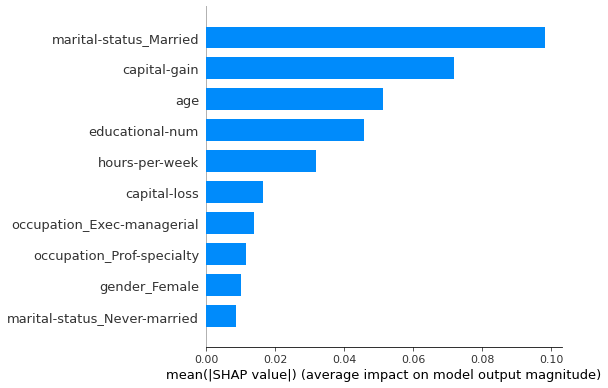

In [21]:
shap.summary_plot(shap_values, X_test_final, plot_type="bar", max_display=10)

* (i) Let's now display the density of the SHAP values.

In [ ]:
# Insert your code here

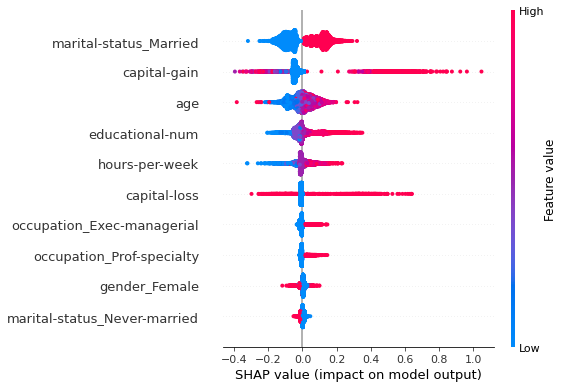

In [22]:
shap.summary_plot(shap_values, X_test_final, max_display=10)

### ✅ Reading the beeswarm: key takeaways

Apply the reading guide from above to the plot you just generated:

1. **Top feature**: Which feature has the widest spread of SHAP values? What does this mean?
2. **`capital-gain`**: Do red dots (high capital gain) cluster on the right? This confirms: high capital gain strongly pushes toward >50K — but only for a *minority* of individuals (most have zero capital gain, explaining the blue mass near zero).
3. **`marital-status_Married`**: Red = married (value=1). Does it push right (toward >50K)? Blue = not married, pushes left? This is the same split the decision tree root showed — SHAP confirms it at scale.
4. **`gender_Female`**: Red = female (value=1). Which direction does it push? Treat this as an **audit cue**: it may reveal historical bias in the data or the model, and deserves deeper investigation.

> 🔑 **Summary**: The beeswarm plot is the most information-dense SHAP view. It shows *which features matter*, *in which direction*, and *for what range of values* — all at once.



### 📖 Before you run this: how to read SHAP dependence plots

A SHAP dependence plot answers: *"How does changing the value of one feature affect predictions — and does this interact with another feature?"*

```
SHAP value
for feature X    ●●
(y-axis)       ●● ●●            colored by feature Z
              ●●   ●●          🔵 blue = low Z
     0 ─────────────────        🔴 red  = high Z
           ●●   ●
           ●●

             Low   →   High
           Feature X value (x-axis)
```

**Reading rules:**
| Element | Meaning |
|---------|---------|
| **X-axis** | Actual value of the feature being explained |
| **Y-axis** | SHAP value = how much this feature pushed the prediction up (+) or down (−) |
| **Upward trend** | Higher values of the feature → higher predicted income |
| **Flat line** | Feature doesn't matter regardless of its value |
| **Color of dots** | Value of a second "interaction" feature; if red dots cluster at one end, those two features interact |
| **Color split at a threshold** | The model's behavior changes at that feature value |

**Key question to ask per plot:**
- At what value does the SHAP value cross zero? (= the threshold where the feature starts helping vs. hurting)
- Does the color change at the same point as the SHAP value changes? If yes → there's an interaction between the two features.

> 💡 **What to notice for `age`**: Does the SHAP value increase monotonically with age, or is there a plateau? Does `capital-gain` (the color) interact with age?

* (l) Display SHAP dependence plots for `age`, `educational-num`, and `hours-per-week`.

In [ ]:
# Insert your code here

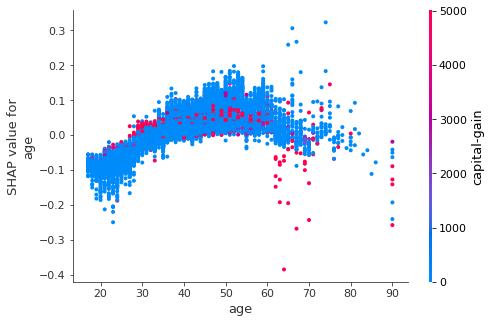

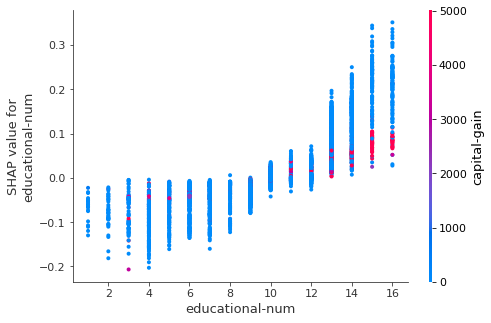

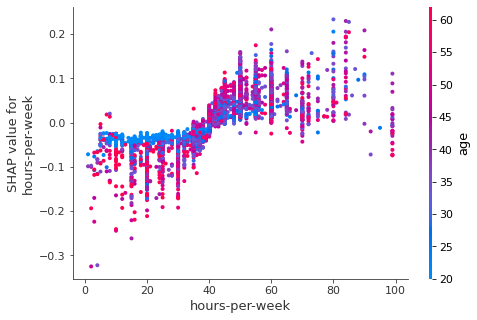

In [23]:
shap.dependence_plot("age", shap_values, X_test_final, interaction_index= "capital-gain")

shap.dependence_plot("educational-num", shap_values, X_test_final, interaction_index= "capital-gain")

shap.dependence_plot("hours-per-week", shap_values, X_test_final, interaction_index= "age")

### 📖 Before you run this: how to read a SHAP force plot

A force plot explains **one individual prediction** — it shows exactly which features pushed the prediction up or down from the baseline.

```
         base value (avg prediction ≈ 0.24)
              │
              ▼
  ┌──────────────────────────────────────────────────────────┐
  │  BLUE blocks ◄─────────────   ─────────────► RED blocks  │
  │  (push down)                                (push up)    │
  │                            │                             │
  │                         f(x) = 0.47                      │
  └──────────────────────────────────────────────────────────┘
```

**Reading rules:**

| Element | Meaning |
|---------|---------|
| **Base value** | Average predicted probability across the training set (~0.24 for this model) |
| **🔴 Red blocks** | Features pushing the prediction *up* (toward >50K) |
| **🔵 Blue blocks** | Features pushing the prediction *down* (toward ≤50K) |
| **Block width** | Magnitude of contribution — wider = stronger effect |
| **f(x) value** | Final predicted probability for this specific person |

**How to read a story from the plot:**  
> "This person starts at the average (0.24). Their `capital-gain` of $15,000 strongly pushes the probability up (+0.18). But their `occupation = Machine-op-inspct` pulls it down (−0.08). The net result is a predicted probability of 0.47 — just below the decision boundary."

> 💡 **What to notice:** Compare two individuals — one predicted ≤50K (low f(x)) and one >50K (high f(x)). What are the dominant red and blue blocks for each? Does the model's reasoning match your intuition?

* (m) Display the force plot for a few individuals.

In [ ]:
# Insert your code here

In [24]:
shap.initjs()

display(shap.force_plot(explainer.expected_value, shap_values[0, :], X_test_final.iloc[0, :]))

shap.force_plot(explainer.expected_value, shap_values[70,:], X_test_final.iloc[70,:])

### ✅ Reading the force plots: key observations

1. **Individual at index 0**: What is their predicted probability? Which features are the biggest contributors (widest blocks)?
2. **Individual at index 70**: How does this person differ from index 0? Are different features dominant?
3. **Consistency check**: Do the local explanations (force plots) match the global ranking (beeswarm plot)? For example, if `marital-status_Married` ranked high globally, does it appear prominently in individual force plots?

> 🔑 **The power of local explanations**: Global plots tell you "this feature matters on average." Force plots tell you "for *this specific person*, here's exactly why the model predicted what it did." This is what you'd use to explain a decision affecting someone like Estelle.

---

## ⚠️ SHAP Limitations — What to Know Before Deploying

SHAP is powerful, but it has important caveats:

| Limitation | Explanation |
|------------|-------------|
| **Correlated features** | If two features are correlated (e.g., `age` and `years_experience`), SHAP values can be unstable — the credit may be split somewhat arbitrarily between them |
| **Computation cost** | `TreeExplainer` is fast (seconds to minutes). But `KernelExplainer` (for any model) can take hours on large datasets. Always check which explainer fits your model. |
| **SHAP ≠ causality** | A high SHAP value for `gender` doesn't mean gender *causes* the prediction — it means the model learned a correlation. Interpreting SHAP causally is a common mistake. |
| **Local instability** | SHAP force plots can vary significantly between similar individuals. Don't over-interpret a single local explanation. |
| **Model-specific** | Different SHAP explainers (`TreeExplainer`, `DeepExplainer`, `LinearExplainer`) work differently. Make sure you're using the right one for your model type. |

> 💡 SHAP is a tool for understanding, not a ground truth. Always combine it with domain knowledge and statistical validation.
>
> 🔁 **Bridge to Part 2**: we'll keep the same SHAP logic, but change two things at once — the data become text, and the target becomes multiclass.



---

## 🔤 Part 2 — SHAP on Text Data: Multiclass Emotion Classification

**Bridge from Part 1:**  
In Part 1, we applied SHAP to tabular data with a binary outcome. The features were structured numbers and categories. SHAP works just as well on other data types — including text — and for tasks with more than 2 classes.

### What changes in Part 2?

| Aspect | Part 1 | Part 2 |
|--------|--------|--------|
| **Input features** | tabular columns | words / tokens |
| **Prediction task** | binary classification | 6-class classification |
| **Main challenge** | direction of effect | one explanation *per class* |
| **SHAP output space** | probabilities | logits |

**What stays the same:**
- we still train an `XGBClassifier`
- we still use `shap.TreeExplainer`
- we still ask the same two questions: **what matters globally?** and **why this prediction locally?**

**What is new:**
- features are now *words*, not business or demographic columns
- there are many more features (3000), so single-feature interpretation is more selective
- each prediction is a probability distribution over 6 emotions

* (a) Import the `emotion.csv` file and display the first few rows.



In [ ]:
# Insert your code here

In [25]:
data = pd.read_csv('emotion.csv', index_col = 0)
data.head()

,text,emotion
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


> The labels in this dataset correspond to emotional states expressed in the text.

| Label | Emotion |
|-------|---------|
| 0 | sadness |
| 1 | joy |
| 2 | fear |
| 3 | anger |
| 4 | surprise |
| 5 | disgust |

> **Why CountVectorizer?**  
> Text cannot be fed directly into most ML algorithms — it must be converted to numbers. `CountVectorizer` implements a **bag-of-words** approach: it counts how many times each word appears in a sentence, ignoring word order.  
> - `max_features=3000` keeps only the 3000 most frequent words → reduces dimensionality while keeping the most informative tokens. Feel free to experiment with different values (500, 5000).  
> - `stop_words='english'` removes common words like "the", "is", "a" that carry no emotional signal.  
> 
> **Limitation**: bag-of-words ignores word order and context. "I am not happy" and "I am happy" get very similar representations. More advanced representations (TF-IDF, word embeddings, BERT) would handle this better — but CountVectorizer is transparent and SHAP-friendly.

* (b) Split into train/test sets. 
* (c) Vectorize texts with `CountVectorizer`.

In [ ]:
# Insert your code here

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Standard train/test split for the text data
# random_state=222: different seed from Part 1 to avoid confusion if you run both
X_train, X_test, y_train, y_test = train_test_split(
    data['text'], data['emotion'],
    test_size=0.2,
    random_state=222
)

# CountVectorizer: converts each sentence into a vector of word counts
# max_features=3000: keep only the 3000 most frequent words (reduces noise, speeds up training)
#   → experiment: try 500 (less features, faster), or 10000 (more features, slower, may overfit)
# stop_words='english': removes words like "the", "is", "a" — no emotional signal
vectorizer = CountVectorizer(
    max_features=3000,
    stop_words='english'
)

# fit_transform on TRAIN only — to prevent data leakage (test set must be unseen vocabulary)
X_train_vec = vectorizer.fit_transform(X_train).toarray()
# transform (not fit_transform!) on TEST — uses the vocabulary learned from train
X_test_vec = vectorizer.transform(X_test).toarray()

print(f"Training matrix: {X_train_vec.shape}  (sentences × vocabulary size)")
print(f"Test matrix:     {X_test_vec.shape}")

> Now that our texts have been vectorized, we will train a **multiclass classification model** using **XGBoost**, a powerful algorithm based on decision trees. The model will learn to predict the emotion expressed in a text based on the numerical representations obtained from the bag-of-words approach.
>
* (d) Train an `XGBClassifier` model on the vectorized data (`X_train_vect`, `y_train`). Note that we are working on a multiclass classification task.


In [ ]:
# Insert your code here

In [ ]:
# objective='multi:softprob': tells XGBoost this is a multiclass problem
#   with soft probabilities (outputs a probability distribution over all classes)
# num_class=6: must explicitly specify the number of classes for multiclass
# eval_metric='mlogloss': multiclass log-loss (XGBoost default for multi:softprob)
model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=6,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
model.fit(X_train_vec, y_train)

* (e) Use your model to predict, for the first 20 observations of `X_test_vect`, the **probability of belonging to each class**.  
* (f) Display the table of **estimated probabilities** for these 20 observations.


### ⚠️ Important: logits vs. probabilities in multiclass SHAP

Before running the SHAP explainer, you need to understand one key difference from Part 1.

**In Part 1** (binary), we used `model_output="probability"` — SHAP values were expressed as probability contributions.

**In Part 2** (multiclass), `TreeExplainer` returns **logits** by default — not probabilities.

**A simple way to think about logits:**
- a **logit** is the model's raw score for one class
- the model produces one raw score per class
- the **softmax** function converts those raw scores into probabilities that sum to 1

$$	ext{probability}_k = rac{e^{	ext{logit}_k}}{\sum_{j=1}^{K} e^{	ext{logit}_j}}$$

**Why does this matter for interpretation?**
- logit SHAP values are not directly readable as percentage-point changes
- what matters most is the **direction** and **relative size** of each contribution
- in practice: a large positive SHAP value for "sadness" means a word strongly increases the model's raw score for the sadness class

> 💡 **Practical rule**: if the absolute numbers feel abstract, that's normal. Focus on *which words push toward the class*, *which words push away from it*, and *which ones dominate the story*.



In [ ]:
# Insert your code here

In [28]:
xgb_proba = model.predict_proba(X_test_vec[:20]).round(2)

class_labels = {0: "sadness", 1: "joy", 2: "fear", 3: "anger", 4: "surprise", 5: "disgust"}

proba_df = pd.DataFrame(xgb_proba, columns=[class_labels[i] for i in range(6)])

proba_df.head(20)

,sadness,joy,fear,anger,surprise,disgust
0,0.21,0.67,0.02,0.06,0.04,0.00
1,0.01,0.02,0.00,0.00,0.00,0.96
2,0.15,0.75,0.02,0.04,0.03,0.00
3,0.10,0.12,0.01,0.44,0.33,0.00
4,0.87,0.11,0.00,0.01,0.01,0.00
5,0.04,0.05,0.00,0.90,0.01,0.00
6,0.78,0.15,0.01,0.03,0.03,0.00
7,0.69,0.22,0.02,0.04,0.03,0.00
8,0.01,0.03,0.03,0.00,0.00,0.92
9,0.92,0.06,0.00,0.01,0.01,0.00


> We will now use SHAP to explain the predictions made by our XGBoost model. To do this, we will create a `TreeExplainer` from the trained model, using a sample of 1000 observations from the vectorized training set. Then, we will compute the Shapley values for the first 20 observations of the vectorized test set.

* (g) Create a `shap.TreeExplainer` using the trained XGBoost model.  
* (h) Provide the explainer with a sample of 1000 observations from `X_train_vect`.  
* (i) Use `explainer.shap_values()` to compute the Shapley values for the first 20 rows of `X_test_vect`.  
* (l) Store the result in a variable (e.g., `shap_values`).


In [ ]:
# Insert your code here

In [ ]:
# Create the SHAP explainer for our multiclass XGBoost model.
# We pass a sample of 1000 training observations as background data.
# Why only 1000? Computing SHAP for 3000 features × 6 classes is expensive.
# 1000 samples gives a reliable estimate of the expected values without being too slow.
explainer = shap.TreeExplainer(model, X_train_vec[:1000])

# Compute SHAP values for the first 20 test observations.
# shap_values will be a LIST of 6 arrays (one per class).
# Each array has shape (20, 3000) — one SHAP value per word per sample.
shap_values = explainer.shap_values(X_test_vec[:20])

> In a **multiclass classification** setting, `TreeExplainer` returns **logits** by default (raw model scores, not probabilities) — as explained in the cell above. Keep this in mind when reading SHAP values.

> There is one `expected_value` per class, representing the average logit score for each class across the training sample.

* (m) Display the `expected_value` for each class.  
* (n) Confirm there are as many expected values as classes.  
* (o) Display the shape of `shap_values` to understand its structure: you'll get a **list of 6 arrays** (one per class), each of shape `(n_samples, n_features)`.

In [ ]:
# Insert your code here

In [30]:
# (m) Display the `expected_value` from the `TreeExplainer` for each class.
for i, expected_value in enumerate(explainer.expected_value):
    print(f"Expected value for class {class_labels[i]}: {expected_value}")

# (n) Notice that there are as many `expected_value` values as there are classes in a multiclass classification problem.
print("\nNote: There are as many `expected_value` values as there are classes in this multiclass classification problem.")
print(f"Number of classes: {len(explainer.expected_value)}")

# (o) Display the shape of the `shap_values` variable to better understand the structure of the results.
print("\nShape of shap_values for the first 20 observations of X_test_vect:")
for i, class_shap in enumerate(shap_values):
    print(f"Class {i}: shape = {class_shap.shape}")


Expected value for class sadness: 1.037256621592387
Expected value for class joy: 1.202191144375829
Expected value for class fear: -1.3855437280249316
Expected value for class anger: -0.2671573702432215
Expected value for class surprise: -0.6567713977399399
Expected value for class disgust: -3.385211264495156

Note: There are as many `expected_value` values as there are classes in this multiclass classification problem.
Number of classes: 6

Shape of shap_values for the first 20 observations of X_test_vect:
Class 0: shape = (20, 3000)
Class 1: shape = (20, 3000)
Class 2: shape = (20, 3000)
Class 3: shape = (20, 3000)
Class 4: shape = (20, 3000)
Class 5: shape = (20, 3000)


### 📖 Before you run this: how to read a multiclass SHAP force plot

Multiclass force plots work the same way as binary ones — but you run one plot **per class** you want to explain.

```
For class "sadness" — individual #4

  base value (logit for sadness = 1.04)
         │
         ▼
  [BLUE blocks] ←── ────────────────────── ──→ [RED blocks]
  words pushing                            words pushing
  AWAY from sadness                       TOWARD sadness

             f(x) = 2.3 (logit for sadness)
```

**Key differences from binary force plots:**
1. **You choose the class**: `shap_values[0]` = contributions for class 0 (sadness). `shap_values[3]` = contributions for class 3 (anger). You select which class to explain.
2. **The y-axis is a logit**, not a probability: a high f(x) means the model gives a high raw score to this class — and softmax will convert that to a high probability.
3. **Features are words**: The feature names are actual words from the text. Red words = vocabulary that pushes toward this emotion. Blue words = vocabulary that pushes against it.

**How to interpret the text example:**
- Run the force plot for the sadness class on a sad sentence → you should see words like "feel", "sad", "hopeless" in red
- Run the force plot for anger on an angry sentence → "angry", "mad", "frustrated" should be red

> 💡 **Sanity check**: Does the force plot make linguistic sense? If words you'd intuitively associate with an emotion appear in red for that class, the model is learning meaningful patterns. If it shows unrelated words, that signals overfitting or data issues.

* (p) Display the SHAP force plots for the **sadness** class (observation 4) and the **anger** class (observation 5).

In [ ]:
# Insert your code here

i know i should be excited about going away for a few days but instead i feel nothing and that makes me feel like an ungrateful horrible person


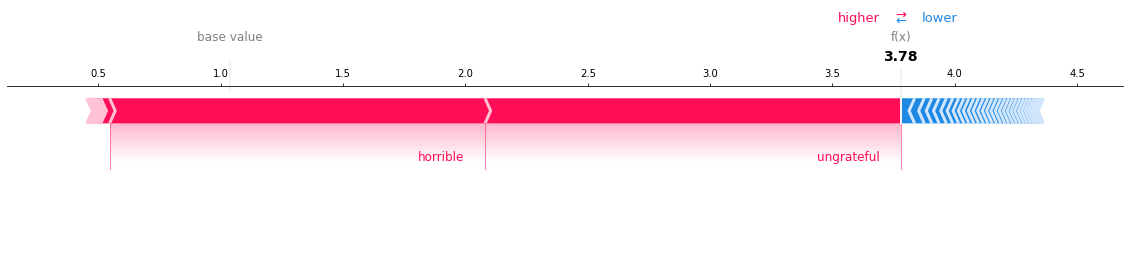

im feeling more fucked up than ive ever had and its nothing to do with my school work


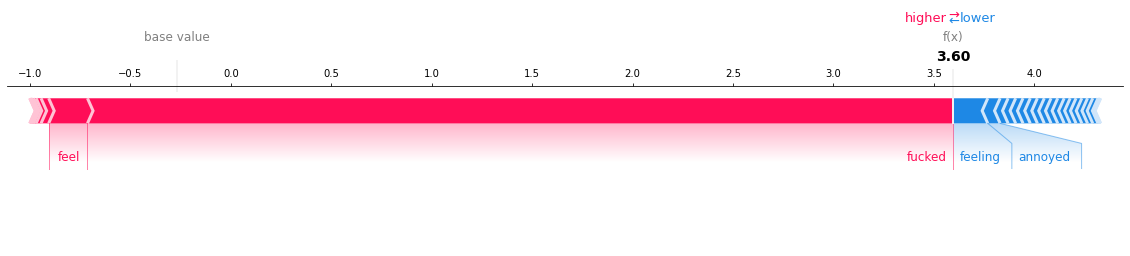

In [31]:
print(X_test.iloc[4])

shap.initjs()
shap.force_plot(explainer.expected_value[0], shap_values[0][4], 
                feature_names=vectorizer.get_feature_names_out(),
                matplotlib=True)



print(X_test.iloc[5])

shap.initjs()
shap.force_plot(explainer.expected_value[3], shap_values[3][5], 
                feature_names=vectorizer.get_feature_names_out(),
                matplotlib=True)

---

## 🏁 Part 3 — Open Challenge: Apply SHAP on Your Own

You now have the full toolkit. Time to use it independently on a dataset whose variables you can explain in plain language.

### Pick a dataset

Choose a dataset with features that are easy to reason about and a prediction task you can discuss responsibly.

**Recommended starter option — Titanic**
```python
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
```

**Other good options**
- **Heart disease**: if you already have a clean CSV or a trusted local source available in your environment
- **Customer churn**: intuitive business features, good for local explanations
- **A dataset from your own project**: best option if you want direct transfer to real work

---

### Your tasks

Work through all steps below. No solution is provided — use what you learned in Parts 1 and 2.

**Step 1 — Load and explore**
```python
# Load the dataset
# Check for missing values
# Display the distribution of the target variable
# Identify any features that may be sensitive or high-stakes
```

**Step 2 — Prepare and train**
```python
# Preprocess (encode categoricals, handle missing values)
# Split into train/test
# Train an XGBClassifier
# Evaluate with classification_report
```

**Step 3 — Global SHAP explanation**
```python
# Create a TreeExplainer
# Compute SHAP values on the test set
# Plot the beeswarm summary plot
```
Answer these questions in a markdown cell:
- What are the top 3 most important features?
- For each, does a high value push toward or against the positive class?
- Does the ranking match your intuition / domain knowledge?

**Step 4 — Local SHAP explanation (3 individuals)**
```python
# Pick 3 test individuals: one clearly predicted positive, one negative, one uncertain
# Display a force plot for each
```
For each person, write one sentence explaining the model's reasoning in plain English (as if explaining to a non-technical colleague).

**Step 5 — Fairness / risk check**
```python
# Identify any sensitive features (age, gender, race, health status, etc.)
# Look at their position and direction in the beeswarm plot
```
Write a brief paragraph:
- Does the model appear to rely on sensitive attributes or plausible proxies?
- If yes, is this justified in context, or potentially problematic?
- What extra validation would you want before using this model in practice?

---

### Checklist before you finish

- [ ] Model is trained and evaluated (F1 score reported)
- [ ] Beeswarm plot generated and top 3 features identified
- [ ] 3 force plots with plain-English interpretations
- [ ] Fairness / risk check completed with written reflection
- [ ] At least one limitation of your SHAP analysis noted

---

## ✅ Conclusion — What Have You Learned?

Let's return to where we started: **Estelle, the loan applicant who received a decision with no explanation.**

With the tools from this notebook, a Data Scientist can now:
1. Train a high-performance model (XGBoost) while keeping interpretability in the workflow
2. Use SHAP to generate a **local force plot** for Estelle — showing exactly which factors contributed to the model's prediction
3. Translate that plot into plain language for a loan officer, a product manager, or an affected customer
4. Audit the global explanations for **fairness signals** — for example, whether sensitive attributes appear as major contributors

---

### The interpretability toolkit — when to use what

| You want to know... | Use... |
|--------------------|--------|
| Which features matter most, globally? | SHAP beeswarm or bar chart |
| How does one feature's value affect predictions? | SHAP dependence plot |
| Why did the model predict X for *this specific person*? | SHAP force plot |
| What does the model look like, simply? | Decision tree (if shallow enough) |
| Quick global structure of predictions? | PCA biplot |

---

### Where to go next

- 📘 **Christoph Molnar's "Interpretable Machine Learning"** (free online): the definitive reference — https://christophm.github.io/interpretable-ml-book/
- 📦 **SHAP documentation**: https://shap.readthedocs.io
- 🔬 **LIME** (Local Interpretable Model-agnostic Explanations): an alternative post hoc method worth comparing to SHAP
- ⚖️ **Fairness tools**: `aequitas`, `fairlearn` — for structured bias auditing beyond visual inspection

---

> 🧠 **Final thought**: Interpretability is not a checkbox. It's a mindset. The goal is not to generate a plot — it's to build genuine understanding of what your model has learned, to communicate it clearly, and to take responsibility for its impact.

